# Demo. Test Lattice Surgery

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import stim
sys.path.append(os.path.abspath(".."))
from src.qec_code.surface_code.rotated import RotatedSurfaceCode
from src.qec_code.surface_code.unrotated import UnrotatedSurfaceCode
from src.qec_code.repetition import RepetitionCode
from src.ir.qec_system import QECSystem
from src.ir.builder import CircuitBuilder
from src.ir.tracker import SyndromeTracker
from src.experiments.memory import MemoryExperiment
from src.noise.config import NoiseConfig
from src.qec_code.surface_code.rotated import RotatedSurfaceCodeExtractionBlock
from src.qec_code.surface_code.unrotated import UnrotatedSurfaceCodeExtractionBlock, UnrotatedTwoPatchCoupler   

Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Flag!
Applying rest rounds of syndrome extraction...
Activating the coupler...
Initializing coupler data qubits...
Building syndrome extraction rounds...
Applying first round of syndrome extraction...
Flag!
Applying rest rounds of syndrome extraction...
Measuring data qubits...


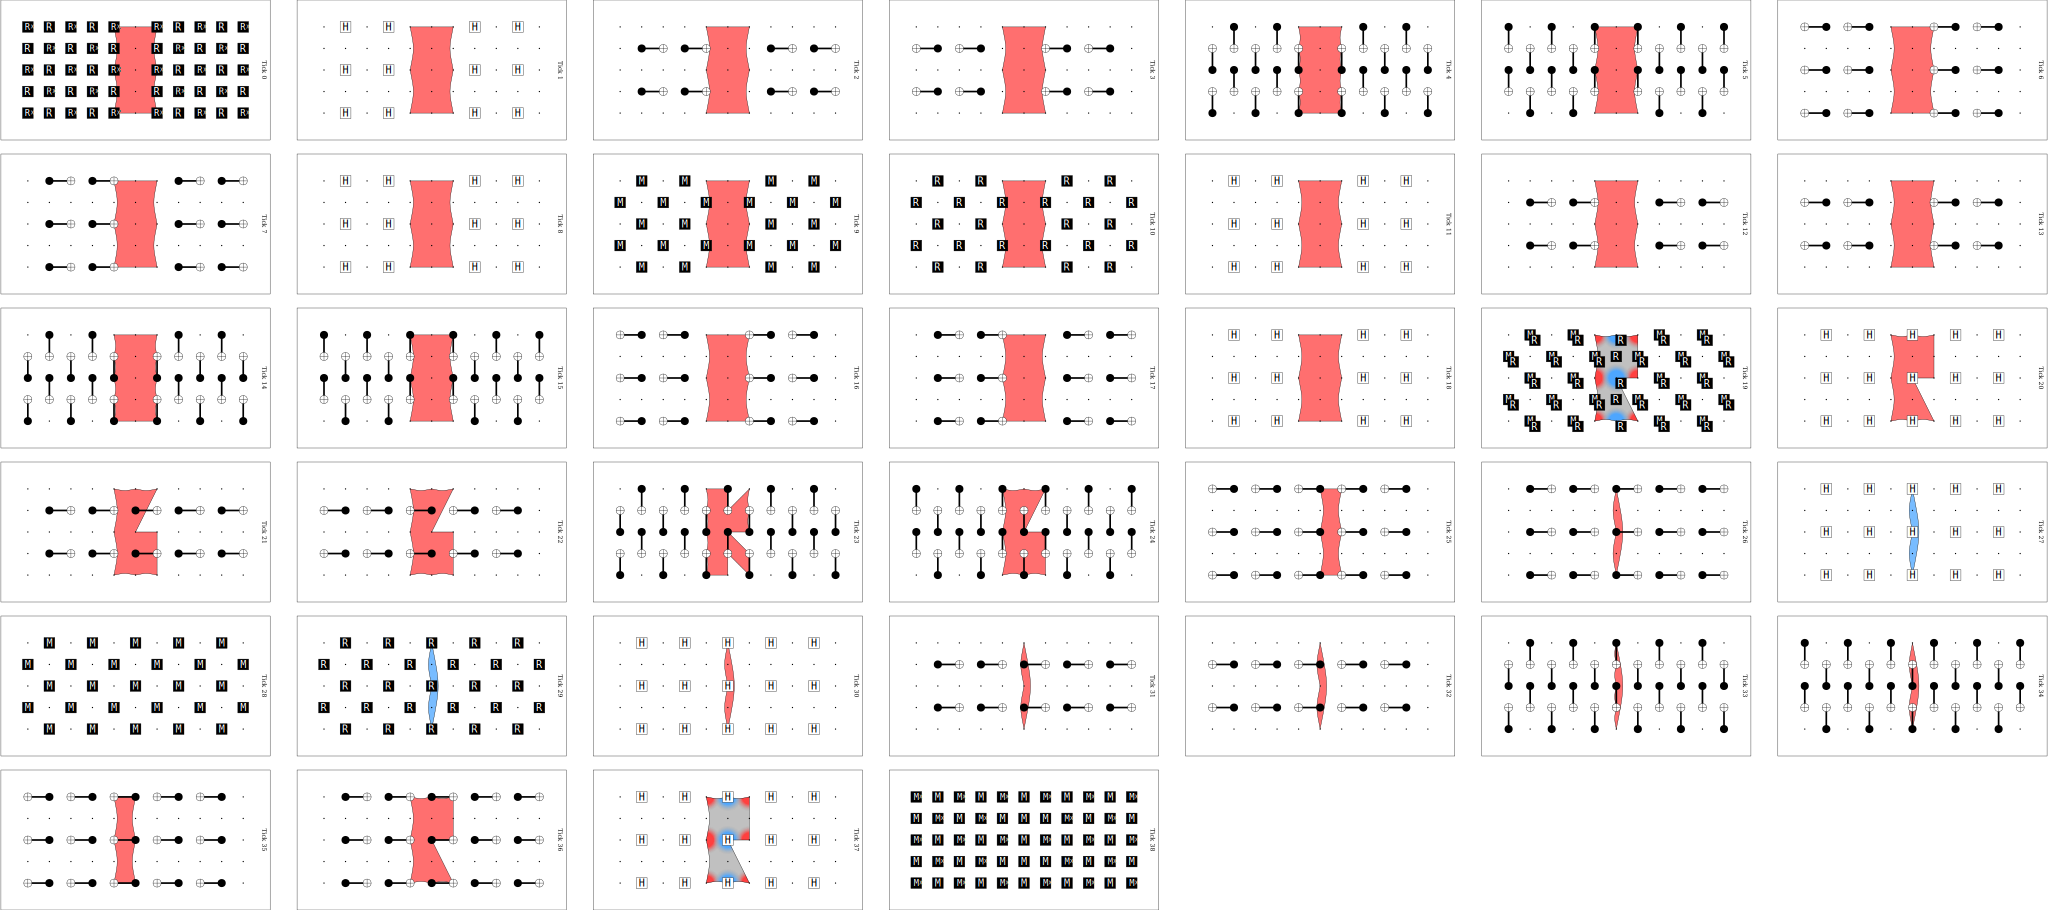

In [6]:
surface_code_1 = UnrotatedSurfaceCode(distance=3)
surface_code_1.rotate_coords(np.pi)
surface_code_1.reset_rotation_angle()
surface_code_2 = UnrotatedSurfaceCode(distance=3)
system = QECSystem()
patch_1 = system.add_patch(surface_code_1, name = "surface_code_1")
patch_2 = system.add_patch(surface_code_2, name = "surface_code_2", offset=(6,0))

rounds = 2
protocol = UnrotatedTwoPatchCoupler() 
code_patches = ["surface_code_1", "surface_code_2"]
# Register the coupler, not activated yet

system.register_coupler(
    protocol, 
    patch_names=code_patches, 
    name="coupler_1_2",
    interaction_type="XX"
)

tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
builder = CircuitBuilder(tracker, system)

builder.write_coordinates()

data_indices = [system.index_map[coord] for coord in system.data_coords if system.owner_map[coord] in code_patches]
# init_dict = {q: "Z" for q in data_indices}
init_dict = {q: "X" for q in data_indices}
builder.initialize(init_dict=init_dict, n=system.num_qubits)


print("Building syndrome extraction rounds...")
se_block = UnrotatedSurfaceCodeExtractionBlock(system)
se_round = se_block.circuit

# Apply the loop using Builder, construct detectors
builder.apply_syndrome_extraction(
    circuit_chunk=se_round, 
    rounds=rounds
)

# Activate the coupler
print("Activating the coupler...")
builder.activate_coupler("coupler_1_2")

# Initialize coupler data qubits in the Z basis
print("Initializing coupler data qubits...")
coupler_data_indices_local = system.coupler_patches["coupler_1_2"].data_indices
coupler_data_indices = [system.local_to_global_map["coupler_1_2"][q] for q in coupler_data_indices_local]
coupler_init_dict = {q: "Z" for q in coupler_data_indices}
builder.initialize(init_dict=coupler_init_dict, n=system.num_qubits)

print("Building syndrome extraction rounds...")
se_block = UnrotatedSurfaceCodeExtractionBlock(system)
se_round = se_block.circuit 

# Apply the loop using Builder, construct detectors
builder.apply_syndrome_extraction(
    circuit_chunk=se_round, 
    rounds=rounds
)

# 5. Final Readout
# ----------------------------------------------------------------------
# Measure data qubits in the memory basis. Construct detectors and logical observables.
print("Measuring data qubits...")
# measurements = {q: ("X" if system.owner_map[q] in code_patches else "Z") for q in system.data_indices}
measurements = init_dict.copy()
measurements.update({q: "Z" for q in coupler_data_indices})

builder.apply_data_readout(final_measurements=measurements)

c = builder.circuit
c.diagram("detslice-with-ops-svg", filter_coords=["D100", "D56"])

In [4]:
c.detector_error_model()

stim.DetectorErrorModel('''
    detector(3, 4, 0) D0
    detector(1, 4, 0) D1
    detector(3, 2, 0) D2
    detector(1, 2, 0) D3
    detector(3, 0, 0) D4
    detector(1, 0, 0) D5
    detector(7, 0, 0) D6
    detector(9, 0, 0) D7
    detector(7, 2, 0) D8
    detector(9, 2, 0) D9
    detector(7, 4, 0) D10
    detector(9, 4, 0) D11
    shift_detectors(0, 0, 1) 0
    detector(3, 4, 0) D12
    detector(1, 4, 0) D13
    detector(4, 3, 0) D14
    detector(2, 3, 0) D15
    detector(0, 3, 0) D16
    detector(3, 2, 0) D17
    detector(1, 2, 0) D18
    detector(4, 1, 0) D19
    detector(2, 1, 0) D20
    detector(0, 1, 0) D21
    detector(3, 0, 0) D22
    detector(1, 0, 0) D23
    detector(7, 0, 0) D24
    detector(9, 0, 0) D25
    detector(6, 1, 0) D26
    detector(8, 1, 0) D27
    detector(10, 1, 0) D28
    detector(7, 2, 0) D29
    detector(9, 2, 0) D30
    detector(6, 3, 0) D31
    detector(8, 3, 0) D32
    detector(10, 3, 0) D33
    detector(7, 4, 0) D34
    detector(9, 4, 0) D35
    detector(

In [3]:
c

stim.Circuit('''
    QUBIT_COORDS(3, 4) 0
    QUBIT_COORDS(1, 4) 1
    QUBIT_COORDS(4, 4) 2
    QUBIT_COORDS(2, 4) 3
    QUBIT_COORDS(0, 4) 4
    QUBIT_COORDS(4, 3) 5
    QUBIT_COORDS(2, 3) 6
    QUBIT_COORDS(0, 3) 7
    QUBIT_COORDS(3, 3) 8
    QUBIT_COORDS(1, 3) 9
    QUBIT_COORDS(3, 2) 10
    QUBIT_COORDS(1, 2) 11
    QUBIT_COORDS(4, 2) 12
    QUBIT_COORDS(2, 2) 13
    QUBIT_COORDS(0, 2) 14
    QUBIT_COORDS(4, 1) 15
    QUBIT_COORDS(2, 1) 16
    QUBIT_COORDS(0, 1) 17
    QUBIT_COORDS(3, 1) 18
    QUBIT_COORDS(1, 1) 19
    QUBIT_COORDS(3, 0) 20
    QUBIT_COORDS(1, 0) 21
    QUBIT_COORDS(4, 0) 22
    QUBIT_COORDS(2, 0) 23
    QUBIT_COORDS(0, 0) 24
    QUBIT_COORDS(7, 0) 25
    QUBIT_COORDS(9, 0) 26
    QUBIT_COORDS(6, 0) 27
    QUBIT_COORDS(8, 0) 28
    QUBIT_COORDS(10, 0) 29
    QUBIT_COORDS(6, 1) 30
    QUBIT_COORDS(8, 1) 31
    QUBIT_COORDS(10, 1) 32
    QUBIT_COORDS(7, 1) 33
    QUBIT_COORDS(9, 1) 34
    QUBIT_COORDS(7, 2) 35
    QUBIT_COORDS(9, 2) 36
    QUBIT_COORDS(6, 2) 37
   